# 🎮 Leetspeak-Normalized Boyer-Moore & Aho-Corasick Hybrid Pipeline
### Toxic Language Detection for Online Game Chat

---

> **Course:** Design and Analysis of Algorithms  
> **Institution:** Batangas State University – Alangilan Campus  
> **Authors:** Doria, John Vincent · Estil, Susan Marie · Fanoga, Haidie N. · Guillo, Rejc C. · Hepuller, Kate Nicole

---

## 🗺️ Pipeline Overview

This notebook demonstrates and benchmarks a **three-stage hybrid pipeline** for real-time toxic language detection in MLBB Filipino and English game chat:

| Stage | Component | Purpose |
|-------|-----------|----------|
| 0 | **Leetspeak Normalizer** | Converts `g4g0` → `gago`, `74ng4` → `tanga` |
| 1 | **Boyer-Moore Pre-Screen** | Fast single-pattern scan on high-risk keywords; early exit if clean |
| 2 | **Aho-Corasick Full Scan** | Multi-pattern trie scan over full dictionary (only triggered after Stage 1 hit) |

**Key result:** The hybrid maintains **~250 µs per message** regardless of dictionary size (53→820 entries), while standalone Aho-Corasick degrades 30× over the same range.


## 1. Imports & Setup

In [2]:
import sys, os, time, tracemalloc, json
from collections import defaultdict
 
# Add parent directory so we can import pipeline modules
sys.path.insert(0, os.path.abspath('..'))
 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
 
from normalizer   import normalize, LEET_MAP
from boyer_moore  import boyer_moore_search, boyer_moore_scan, boyer_moore_full_scan, HIGH_RISK_KEYWORDS
from aho_corasick import build_trie, build_failure_links, aho_corasick_search, aho_corasick_scan
from hybrid       import HybridPipeline, hybrid_scan, print_result
from experiments.test_cases import test_cases
 
print("✅ All pipeline modules imported successfully.")
print(f"   Total test cases : {len(test_cases)}")
print(f"   Toxic messages   : {sum(1 for t in test_cases if t['label'] == 'toxic')}")
print(f"   Clean messages   : {sum(1 for t in test_cases if t['label'] == 'clean')}")


✅ All pipeline modules imported successfully.
   Total test cases : 90
   Toxic messages   : 75
   Clean messages   : 15


## 2. Load Toxic Word Dataset

In [3]:
DATASET_PATH = os.path.join('data', 'toxic_word_dataset_final.xlsx')
 
df = pd.read_excel(DATASET_PATH, header=1)
print("Dataset columns:", df.columns.tolist())
display(df)
 
# Build full dictionary: plain + all leet variants
plain = df['Plain Word'].dropna().astype(str).str.lower().str.strip().tolist()
leet1 = df['Leet Variant 1 (Basic)'].dropna().astype(str).str.lower().str.strip().tolist()
leet2 = df['Leet Variant 2 (Intermediate)'].dropna().astype(str).str.lower().str.strip().tolist()
full_dictionary = list(set(plain + leet1 + leet2))
 
print(f"\n✅ Dictionary loaded: {len(full_dictionary)} entries (plain + leet variants)")


Dataset columns: ['#', 'Language', 'Plain Word', 'Leet Variant 1 (Basic)', 'Leet Variant 2 (Intermediate)', 'Category']


,#,Language,Plain Word,Leet Variant 1 (Basic),Leet Variant 2 (Intermediate),Category
0,1,Filipino,bobo,b0b0,8080,Profanity
1,2,Filipino,tanga,74ng4,74n94,Profanity
2,3,Filipino,gago,g4g0,9490,Profanity
3,4,Filipino,ulol,ul0l,u101,Profanity
4,5,Filipino,inutil,1nu71l,1nu711,Insult
5,6,Filipino,tarantado,74r4n74d0,74r4n74d0,Insult
6,7,Filipino,hunghang,hungh4ng,hun9h4n9,Insult
7,8,Filipino,leche,l3ch3,13ch3,Profanity
8,9,Filipino,gaga,g4g4,9494,Profanity
9,10,Filipino,tangina,74ng1n4,74n91n4,Profanity



✅ Dictionary loaded: 53 entries (plain + leet variants)


## 3. Pipeline Walkthrough — Step-by-Step
 
The hybrid pipeline runs in three stages on every raw message:
 
| Stage | Component | Role |
|-------|-----------|------|
| 0 | Leetspeak Normalizer | Convert obfuscated chars to plain text |
| 1 | Boyer-Moore | Pre-screen against high-risk keywords; early-exit if no match |
| 2 | Aho-Corasick | Full dictionary scan (only runs if BM finds a match) |


In [5]:
pipeline = HybridPipeline(full_dictionary)
 
WALKTHROUGH_SAMPLES = [
    "ang g4g0 mo pre",         # leetspeak gago
    "b0b0 ka talaga",           # leetspeak bobo
    "74ng1n4, bakit ka ganyan", # leetspeak tangina
    "$7up1d ka",                # leetspeak stupid
    "good game everyone GG WP", # clean — should NOT be flagged
    "nice kill bro, push na",   # clean — should NOT be flagged
]
 
for msg in WALKTHROUGH_SAMPLES:
    result = pipeline.process_timed(msg)
    print_result(result)


-----------------------------------------------------------------
  Raw Text       : ang g4g0 mo pre
  Normalized     : ang gago mo pre
  Flagged        : True
  Stage Triggered: bm+ac
  Matches (1):
    → 'gago' at index 4–7
  Time (µs)      : 217.8
-----------------------------------------------------------------
-----------------------------------------------------------------
  Raw Text       : b0b0 ka talaga
  Normalized     : bobo ka talaga
  Flagged        : True
  Stage Triggered: bm+ac
  Matches (1):
    → 'bobo' at index 0–3
  Time (µs)      : 299.6
-----------------------------------------------------------------
-----------------------------------------------------------------
  Raw Text       : 74ng1n4, bakit ka ganyan
  Normalized     : tangina, bakit ka ganyan
  Flagged        : True
  Stage Triggered: bm+ac
  Matches (1):
    → 'tangina' at index 0–6
  Time (µs)      : 162.4
-----------------------------------------------------------------
------------------------------

## 4. Leetspeak Normalizer — Character Map Demo

In [4]:
print("Predefined Leet Substitution Map:")
print("-" * 40)
for k, v in LEET_MAP.items():
    print(f"  '{k}'  →  '{v}'")
 
print("\nNormalization examples:")
print("-" * 40)
examples = [
    "g4g0", "b0b0", "74ng4", "1d107", "$7up1d",
    "74ng1n4", "9490", "8080", "ang g4g0 mo pre",
]
for raw in examples:
    print(f"  {raw:<25} → {normalize(raw)}")


Predefined Leet Substitution Map:
----------------------------------------
  '0'  →  'o'
  '4'  →  'a'
  '1'  →  'i'
  '3'  →  'e'
  '@'  →  'a'
  '$'  →  's'
  '+'  →  't'
  '5'  →  's'
  '7'  →  't'
  '9'  →  'g'
  '6'  →  'b'
  '8'  →  'b'
  '!'  →  'i'
  '°'  →  'o'
  'ß'  →  'b'

Normalization examples:
----------------------------------------
  g4g0                      → gago
  b0b0                      → bobo
  74ng4                     → tanga
  1d107                     → idiot
  $7up1d                    → stupid
  74ng1n4                   → tangina
  9490                      → gago
  8080                      → bobo
  ang g4g0 mo pre           → ang gago mo pre


## 5. Boyer-Moore — Single Pattern Search Walkthrough
 
Boyer-Moore compares **right-to-left** within the pattern while advancing **left-to-right** 
across the text. On a mismatch, it takes the larger of:
- **Bad Character shift**: align mismatched text char with its last occurrence in pattern
- **Good Suffix shift**: align already-matched suffix with next occurrence in pattern


In [6]:
from boyer_moore import build_bad_character_table, build_good_suffix_table
 
text    = "ang gago mo"
pattern = "gago"
 
bc = build_bad_character_table(pattern)
gs = build_good_suffix_table(pattern)
 
print(f"Text    : '{text}'")
print(f"Pattern : '{pattern}'")
print(f"\nBad Character Table : {bc}")
print(f"Good Suffix Table   : {gs}")
print()
 
positions = boyer_moore_search(text, pattern)
print(f"Match found at position(s): {positions}")
print()
 
# Show what BM scan returns for high-risk keywords
sample = "ang g4g0 mo, sobrang b0b0 talaga"
norm   = normalize(sample)
scan   = boyer_moore_scan(norm)
print(f"Raw input  : '{sample}'")
print(f"Normalized : '{norm}'")
print(f"BM matches : {scan}")


Text    : 'ang gago mo'
Pattern : 'gago'

Bad Character Table : {'g': 2, 'a': 1, 'o': 3}
Good Suffix Table   : [4, 4, 4, 4, 1]

Match found at position(s): [4]

Raw input  : 'ang g4g0 mo, sobrang b0b0 talaga'
Normalized : 'ang gago mo, sobrang bobo talaga'
BM matches : [{'keyword': 'gago', 'positions': [4]}, {'keyword': 'bobo', 'positions': [21]}]


## 6. Aho-Corasick — Multi-Pattern Trie Search
 
Aho-Corasick builds a **finite-state automaton** (trie + failure links) from the full 
dictionary and scans the entire text in a **single linear pass**, matching all patterns 
simultaneously.


In [7]:
small_dict = ["gago", "bobo", "tanga", "ulol", "inutil", "idiot", "stupid", "noob"]
root = build_trie(small_dict)
root = build_failure_links(root)
 
sample_texts = [
    "ang gago mo bobo ka talaga",
    "wala kang silbi inutil ka",
    "good game everyone",
    "idiot at stupid ka",
]
 
print(f"{'Text':<45} {'Matches Found'}")
print("-" * 75)
for t in sample_texts:
    result = aho_corasick_search(t, root)
    found  = ", ".join(f'"{r["keyword"]}"@{r["positions"]}' for r in result) or "— none —"
    print(f"{t:<45} {found}")


Text                                          Matches Found
---------------------------------------------------------------------------
ang gago mo bobo ka talaga                    "gago"@[4], "bobo"@[12]
wala kang silbi inutil ka                     "inutil"@[16]
good game everyone                            — none —
idiot at stupid ka                            "idiot"@[0], "stupid"@[9]


## 7. Load All 3 dictionaries 

In [6]:
# -----------------------------------------------------------------------------
# CELL 1 — Load all three dictionaries
# -----------------------------------------------------------------------------
 
DATASET_PATH = os.path.join('data', 'toxic_word_dataset_final.xlsx')
 
def load_dictionary(sheet_name):
    df = pd.read_excel(DATASET_PATH, sheet_name=sheet_name, header=1)
    plain = df['Plain Word'].dropna().astype(str).str.lower().str.strip().tolist()
    leet1 = df['Leet Variant 1 (Basic)'].dropna().astype(str).str.lower().str.strip().tolist()
    leet2 = df['Leet Variant 2 (Intermediate)'].dropna().astype(str).str.lower().str.strip().tolist()
    return list(set(plain + leet1 + leet2))
 
dict_small  = load_dictionary('Small (20 words)')
dict_medium = load_dictionary('Medium (100 words)')
dict_large  = load_dictionary('Large (500 words)')
 
DICTIONARIES = {
    'Small (53)'   : dict_small,
    'Medium (259)' : dict_medium,
    'Large (820)'  : dict_large,
}
 
print("Dictionaries loaded:")
for name, d in DICTIONARIES.items():
    print(f"  {name} -> {len(d)} unique entries")
 

Dictionaries loaded:
  Small (53) -> 53 unique entries
  Medium (259) -> 259 unique entries
  Large (820) -> 820 unique entries


## 8. Benchmark helper

In [19]:
RUNS = 5
 
def benchmark_one(func, *args):
    """Run func(*args) RUNS times; return avg time (us) and avg peak memory (KB)."""
    times, mems = [], []
    for _ in range(RUNS):
        tracemalloc.start()
        t0 = time.perf_counter()
        func(*args)
        t1 = time.perf_counter()
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        times.append((t1 - t0) * 1e6)
        mems.append(peak / 1024)
    return round(sum(times) / RUNS, 3), round(sum(mems) / RUNS, 3)
 

## 9. Run Benchmark (all 3 dicts) 

In [8]:
 
all_records = {}   # dict_name -> DataFrame of results
 
for dict_name, dictionary in DICTIONARIES.items():
    print(f"\nBenchmarking with {dict_name} dictionary ({len(dictionary)} entries)...")
    pipeline_bench = HybridPipeline(dictionary)
    records = []
 
    for i, tc in enumerate(test_cases):
        raw  = tc['message']
        norm = normalize(raw)
 
        bm_t, bm_m = benchmark_one(boyer_moore_full_scan, norm, dictionary)
        ac_t, ac_m = benchmark_one(aho_corasick_scan,     norm, dictionary)
        hy_t, hy_m = benchmark_one(pipeline_bench.process, raw)
 
        hy_out = pipeline_bench.process(raw)
 
        records.append({
            'id'      : i + 1,
            'message' : raw,
            'type'    : tc['type'],
            'label'   : tc['label'],
            'note'    : tc['note'],
            'bm_t'    : bm_t,  'bm_m': bm_m,
            'ac_t'    : ac_t,  'ac_m': ac_m,
            'hy_t'    : hy_t,  'hy_m': hy_m,
            'flagged' : hy_out['flagged'],
            'stage'   : hy_out['stage_triggered'],
            'matches' : [m['pattern'] for m in hy_out['matches']],
        })
 
    all_records[dict_name] = pd.DataFrame(records)
    print(f"  Done - {len(records)} test cases processed.")
 
print("\nAll benchmarks complete.")



Benchmarking with Small (53) dictionary (53 entries)...
  Done - 90 test cases processed.

Benchmarking with Medium (259) dictionary (259 entries)...
  Done - 90 test cases processed.

Benchmarking with Large (820) dictionary (820 entries)...
  Done - 90 test cases processed.

All benchmarks complete.


## 10. Summary Stats Table 

In [9]:
 
summary_rows = []
 
for dict_name, df in all_records.items():
    tp = int(((df['label'] == 'toxic') &  df['flagged']).sum())
    fp = int(((df['label'] == 'clean') &  df['flagged']).sum())
    tn = int(((df['label'] == 'clean') & ~df['flagged']).sum())
    fn = int(((df['label'] == 'toxic') & ~df['flagged']).sum())
 
    prec = tp / (tp + fp) * 100 if (tp + fp) else 0
    rec  = tp / (tp + fn) * 100 if (tp + fn) else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0
 
    summary_rows.append({
        'Dictionary'       : dict_name,
        'Avg BM Time (us)' : round(df['bm_t'].mean(), 2),
        'Avg AC Time (us)' : round(df['ac_t'].mean(), 2),
        'Avg HY Time (us)' : round(df['hy_t'].mean(), 2),
        'Avg BM Mem (KB)'  : round(df['bm_m'].mean(), 2),
        'Avg AC Mem (KB)'  : round(df['ac_m'].mean(), 2),
        'Avg HY Mem (KB)'  : round(df['hy_m'].mean(), 2),
        'TP' : tp, 'FP': fp, 'TN': tn, 'FN': fn,
        'Precision (%)' : round(prec, 1),
        'Recall (%)'    : round(rec,  1),
        'F1 Score (%)'  : round(f1,   1),
    })
 
df_summary = pd.DataFrame(summary_rows)
 
print("=" * 70)
print("SUMMARY: ACCURACY + PERFORMANCE BY DICTIONARY SIZE")
print("=" * 70)
display(df_summary)
 
os.makedirs('results/tables', exist_ok=True)
df_summary.to_csv('results/tables/multi_dict_summary.csv', index=False)
print("Saved -> results/tables/multi_dict_summary.csv")
 

SUMMARY: ACCURACY + PERFORMANCE BY DICTIONARY SIZE


,Dictionary,Avg BM Time (us),Avg AC Time (us),Avg HY Time (us),Avg BM Mem (KB),Avg AC Mem (KB),Avg HY Mem (KB),TP,FP,TN,FN,Precision (%),Recall (%),F1 Score (%)
0,Small (53),413.89,1255.80,258.87,0.54,62.64,0.91,31,0,15,44,100.0,41.3,58.5
1,Medium (259),1907.08,6465.85,240.10,0.60,355.22,0.90,31,0,15,44,100.0,41.3,58.5
2,Large (820),7151.35,37471.43,270.61,0.90,1433.31,0.91,31,0,15,44,100.0,41.3,58.5


Saved -> results/tables/multi_dict_summary.csv


## 11. Execution Time Graph

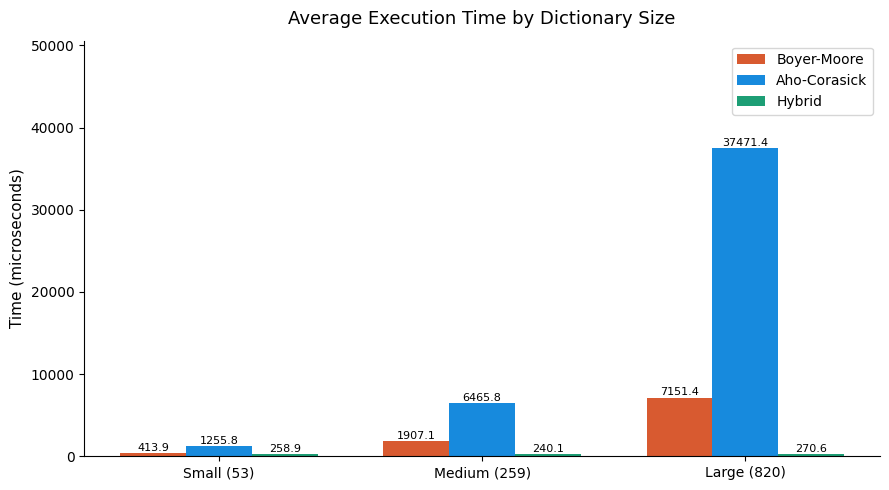

Saved -> results/graphs/multi_dict_execution_time.png


In [10]:
os.makedirs('results/graphs', exist_ok=True)
 
dict_labels = list(all_records.keys())
bm_times = [all_records[d]['bm_t'].mean() for d in dict_labels]
ac_times = [all_records[d]['ac_t'].mean() for d in dict_labels]
hy_times = [all_records[d]['hy_t'].mean() for d in dict_labels]
 
x     = np.arange(len(dict_labels))
width = 0.25
 
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width, bm_times, width, label='Boyer-Moore', color='#D85A30')
b2 = ax.bar(x,         ac_times, width, label='Aho-Corasick', color='#178ADD')
b3 = ax.bar(x + width, hy_times, width, label='Hybrid',       color='#1D9E75')
 
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 8,
                f'{bar.get_height():.1f}',
                ha='center', va='bottom', fontsize=8, fontweight='500')
 
ax.set_title('Average Execution Time by Dictionary Size', fontsize=13, fontweight='500', pad=12)
ax.set_ylabel('Time (microseconds)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(dict_labels, fontsize=10)
ax.set_ylim(0, max(ac_times) * 1.35)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/graphs/multi_dict_execution_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> results/graphs/multi_dict_execution_time.png")

## 12. Memory Usage Graph 

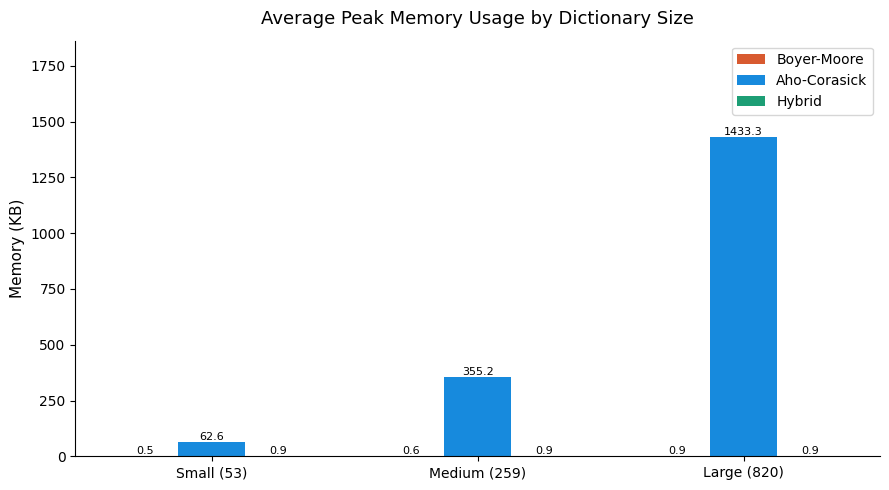

In [11]:

bm_mems = [all_records[d]['bm_m'].mean() for d in dict_labels]
ac_mems = [all_records[d]['ac_m'].mean() for d in dict_labels]
hy_mems = [all_records[d]['hy_m'].mean() for d in dict_labels]
 
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width, bm_mems, width, label='Boyer-Moore', color='#D85A30')
b2 = ax.bar(x,         ac_mems, width, label='Aho-Corasick', color='#178ADD')
b3 = ax.bar(x + width, hy_mems, width, label='Hybrid',       color='#1D9E75')
 
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{bar.get_height():.1f}',
                ha='center', va='bottom', fontsize=8, fontweight='500')
 
ax.set_title('Average Peak Memory Usage by Dictionary Size', fontsize=13, fontweight='500', pad=12)
ax.set_ylabel('Memory (KB)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(dict_labels, fontsize=10)
ax.set_ylim(0, max(ac_mems) * 1.3)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/graphs/multi_dict_memory_usage.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Accuracy Line Chart

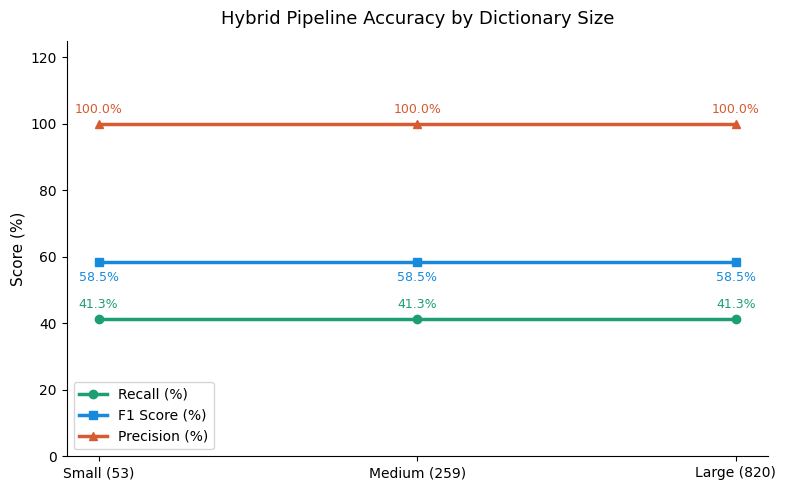

Saved -> results/graphs/multi_dict_accuracy.png


In [14]:
recalls = [r['Recall (%)']    for r in summary_rows]
f1s     = [r['F1 Score (%)']  for r in summary_rows]
precs   = [r['Precision (%)'] for r in summary_rows]
 
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(dict_labels, recalls, marker='o', linewidth=2.5, color='#1D9E75', label='Recall (%)')
ax.plot(dict_labels, f1s,     marker='s', linewidth=2.5, color='#178ADD', label='F1 Score (%)')
ax.plot(dict_labels, precs,   marker='^', linewidth=2.5, color='#D85A30', label='Precision (%)')
 
for i, (r, f, p) in enumerate(zip(recalls, f1s, precs)):
    ax.annotate(f'{r:.1f}%', (dict_labels[i], r),
                textcoords='offset points', xytext=(0, 8),  ha='center', fontsize=9, color='#1D9E75')
    ax.annotate(f'{f:.1f}%', (dict_labels[i], f),
                textcoords='offset points', xytext=(0, -14), ha='center', fontsize=9, color='#178ADD')
    ax.annotate(f'{p:.1f}%', (dict_labels[i], p),
                textcoords='offset points', xytext=(0, 8),  ha='center', fontsize=9, color='#D85A30')
 
ax.set_title('Hybrid Pipeline Accuracy by Dictionary Size', fontsize=13, fontweight='500', pad=12)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_ylim(0, 125)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.savefig('results/graphs/multi_dict_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> results/graphs/multi_dict_accuracy.png")

## 14. Detection by Type Graph

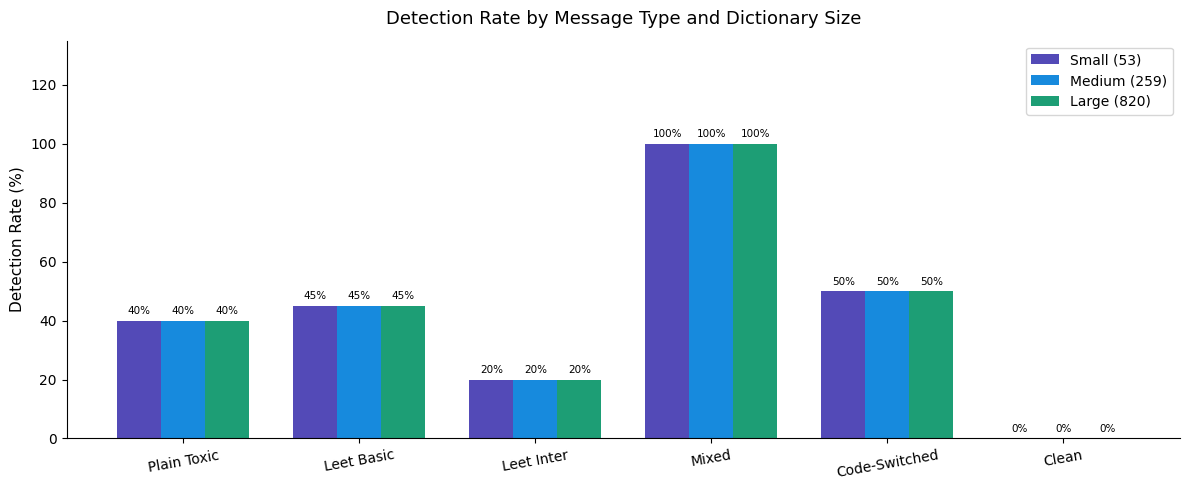

Saved -> results/graphs/multi_dict_detection_by_type.png


In [15]:
type_order  = ['plain_toxic', 'leet_basic', 'leet_inter', 'mixed', 'codeswitched', 'clean']
type_labels = ['Plain Toxic', 'Leet Basic', 'Leet Inter', 'Mixed', 'Code-Switched', 'Clean']
dict_colors = ['#534AB7', '#178ADD', '#1D9E75']
 
x     = np.arange(len(type_order))
width = 0.25
 
fig, ax = plt.subplots(figsize=(12, 5))
 
for idx, (dict_name, df) in enumerate(all_records.items()):
    rates = []
    for t in type_order:
        sub     = df[df['type'] == t]
        flagged = sub['flagged'].sum()
        rates.append(flagged / len(sub) * 100 if len(sub) else 0)
    offset = (idx - 1) * width
    bars   = ax.bar(x + offset, rates, width, label=dict_name, color=dict_colors[idx])
    for bar, val in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1.5,
                f'{val:.0f}%',
                ha='center', va='bottom', fontsize=7.5, fontweight='500')
 
ax.set_title('Detection Rate by Message Type and Dictionary Size', fontsize=13, fontweight='500', pad=12)
ax.set_ylabel('Detection Rate (%)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(type_labels, fontsize=10, rotation=10)
ax.set_ylim(0, 135)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/graphs/multi_dict_detection_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> results/graphs/multi_dict_detection_by_type.png")

## 15. Per-type Accuracy Tables

In [16]:
for dict_name, df in all_records.items():
    print(f"\n{'=' * 60}")
    print(f"ACCURACY BY MESSAGE TYPE --- {dict_name}")
    print(f"{'=' * 60}")
    rows = []
    for t in type_order:
        sub  = df[df['type'] == t]
        if len(sub) == 0:
            continue
        tp_t = int(((sub['label'] == 'toxic') &  sub['flagged']).sum())
        fp_t = int(((sub['label'] == 'clean') &  sub['flagged']).sum())
        tn_t = int(((sub['label'] == 'clean') & ~sub['flagged']).sum())
        fn_t = int(((sub['label'] == 'toxic') & ~sub['flagged']).sum())
        prec_t = tp_t / (tp_t + fp_t) * 100 if (tp_t + fp_t) else float('nan')
        rec_t  = tp_t / (tp_t + fn_t) * 100 if (tp_t + fn_t) else float('nan')
        rows.append({
            'Type'      : t,
            'Total'     : len(sub),
            'TP': tp_t, 'FP': fp_t, 'TN': tn_t, 'FN': fn_t,
            'Precision' : f'{prec_t:.1f}%' if not pd.isna(prec_t) else '--',
            'Recall'    : f'{rec_t:.1f}%'  if not pd.isna(rec_t)  else '--',
        })
    df_type = pd.DataFrame(rows)
    display(df_type)
    safe_name = dict_name.split('(')[0].strip().lower()
    df_type.to_csv(f'results/tables/accuracy_by_type_{safe_name}.csv', index=False)
 
print("\nAll per-type accuracy tables saved.")
 
 


ACCURACY BY MESSAGE TYPE --- Small (53)


,Type,Total,TP,FP,TN,FN,Precision,Recall
0,plain_toxic,20,8,0,0,12,100.0%,40.0%
1,leet_basic,20,9,0,0,11,100.0%,45.0%
2,leet_inter,20,4,0,0,16,100.0%,20.0%
3,mixed,5,5,0,0,0,100.0%,100.0%
4,codeswitched,10,5,0,0,5,100.0%,50.0%
5,clean,15,0,0,15,0,--,--



ACCURACY BY MESSAGE TYPE --- Medium (259)


,Type,Total,TP,FP,TN,FN,Precision,Recall
0,plain_toxic,20,8,0,0,12,100.0%,40.0%
1,leet_basic,20,9,0,0,11,100.0%,45.0%
2,leet_inter,20,4,0,0,16,100.0%,20.0%
3,mixed,5,5,0,0,0,100.0%,100.0%
4,codeswitched,10,5,0,0,5,100.0%,50.0%
5,clean,15,0,0,15,0,--,--



ACCURACY BY MESSAGE TYPE --- Large (820)


,Type,Total,TP,FP,TN,FN,Precision,Recall
0,plain_toxic,20,8,0,0,12,100.0%,40.0%
1,leet_basic,20,9,0,0,11,100.0%,45.0%
2,leet_inter,20,4,0,0,16,100.0%,20.0%
3,mixed,5,5,0,0,0,100.0%,100.0%
4,codeswitched,10,5,0,0,5,100.0%,50.0%
5,clean,15,0,0,15,0,--,--



All per-type accuracy tables saved.


## 16. Scalability Line Chart

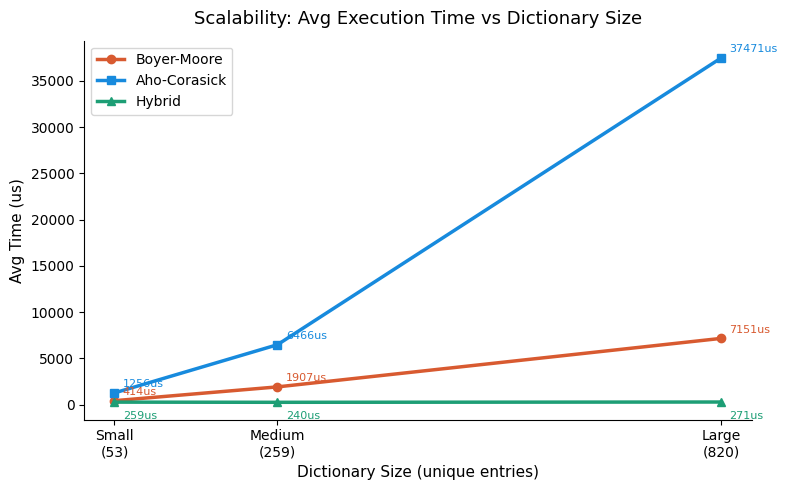

Saved -> results/graphs/scalability_time.png


In [17]:

dict_sizes = [53, 259, 820]
hy_avg     = [all_records[d]['hy_t'].mean() for d in dict_labels]
ac_avg     = [all_records[d]['ac_t'].mean() for d in dict_labels]
bm_avg     = [all_records[d]['bm_t'].mean() for d in dict_labels]
 
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(dict_sizes, bm_avg, marker='o', linewidth=2.5, color='#D85A30', label='Boyer-Moore')
ax.plot(dict_sizes, ac_avg, marker='s', linewidth=2.5, color='#178ADD', label='Aho-Corasick')
ax.plot(dict_sizes, hy_avg, marker='^', linewidth=2.5, color='#1D9E75', label='Hybrid')
 
for s, b, a, h in zip(dict_sizes, bm_avg, ac_avg, hy_avg):
    ax.annotate(f'{b:.0f}us', (s, b), textcoords='offset points', xytext=( 6,  4), fontsize=8, color='#D85A30')
    ax.annotate(f'{a:.0f}us', (s, a), textcoords='offset points', xytext=( 6,  4), fontsize=8, color='#178ADD')
    ax.annotate(f'{h:.0f}us', (s, h), textcoords='offset points', xytext=( 6,-12), fontsize=8, color='#1D9E75')
 
ax.set_title('Scalability: Avg Execution Time vs Dictionary Size', fontsize=13, fontweight='500', pad=12)
ax.set_xlabel('Dictionary Size (unique entries)', fontsize=11)
ax.set_ylabel('Avg Time (us)', fontsize=11)
ax.set_xticks(dict_sizes)
ax.set_xticklabels(['Small\n(53)', 'Medium\n(259)', 'Large\n(820)'], fontsize=10)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/graphs/scalability_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> results/graphs/scalability_time.png")
 

## TESTER

In [20]:
## 🧪 Interactive Message Tester
from IPython.display import display, clear_output

text_input = widgets.Text(
    value='',
    placeholder='Type a message here e.g. ang g4g0 mo pre',
    description='Message:',
    layout=widgets.Layout(width='70%')
)

run_btn = widgets.Button(
    description='Analyze',
    button_style='primary',
    layout=widgets.Layout(width='100px')
)

output = widgets.Output()

def on_analyze(b):
    with output:
        clear_output()
        raw = text_input.value.strip()
        if not raw:
            print("⚠️  Please type a message first.")
            return

        norm = normalize(raw)
        print("=" * 65)
        print(f"  Input      : {raw}")
        print(f"  Normalized : {norm}")
        print("=" * 65)
        print(f"  {'Dictionary':<16} {'Flagged':<10} {'Time (µs)':<12} {'Matches'}")
        print(f"  {'-' * 62}")

        for dict_name, dictionary in DICTIONARIES.items():
            p = HybridPipeline(dictionary)
            r = p.process_timed(raw)
            flagged = r['flagged']
            t       = r.get('processing_time_us', '—')
            matches = ', '.join(f"'{m['pattern']}'" for m in r['matches']) if r['matches'] else '— none —'
            print(f"  {dict_name:<16} {'✅ YES' if flagged else '❌ NO':<10} {str(t)+'µs':<12} {matches}")

        print("=" * 65)

run_btn.on_click(on_analyze)

display(widgets.HBox([text_input, run_btn]), output)

Output()